# PRCP-1005-Forest Cover Prediction

# Forest Cover Type Prediction Report

### Task 1: Complete Data Analysis Report

#### 1. Introduction

* This project focuses on analyzing forest cartographic data and building a predictive model to classify seven different forest cover types across four wilderness areas. Accurate prediction of cover types helps in forest management, biodiversity conservation, and ecological planning.

#### 2. Dataset Overview
* Dataset Size: 15,120 rows × 56 columns
* Target Variable: Cover_Type (7 classes: 1–7)
* ID Column: Id (not useful for prediction)

### Feature Categories

#### 1. Continuous Features (10):
* Elevation, Aspect, Slope
* Horizontal/Vertical Distance to Hydrology
* Distance to Roadways
* Hillshade (9am, Noon, 3pm)
* Distance to Fire Points
#### 2. Wilderness Areas (4):
* Binary encoded: Wilderness_Area1 to Wilderness_Area4
#### 3. Soil Types (40):
* Binary encoded: Soil_Type1 to Soil_Type40

In [134]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('train.csv')
df

,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,1,2596,51,3,258,0,510,221,232,148,...,0,0,0,0,0,0,0,0,0,5
1,2,2590,56,2,212,-6,390,220,235,151,...,0,0,0,0,0,0,0,0,0,5
2,3,2804,139,9,268,65,3180,234,238,135,...,0,0,0,0,0,0,0,0,0,2
3,4,2785,155,18,242,118,3090,238,238,122,...,0,0,0,0,0,0,0,0,0,2
4,5,2595,45,2,153,-1,391,220,234,150,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15115,15116,2607,243,23,258,7,660,170,251,214,...,0,0,0,0,0,0,0,0,0,3
15116,15117,2603,121,19,633,195,618,249,221,91,...,0,0,0,0,0,0,0,0,0,3
15117,15118,2492,134,25,365,117,335,250,220,83,...,0,0,0,0,0,0,0,0,0,3
15118,15119,2487,167,28,218,101,242,229,237,119,...,0,0,0,0,0,0,0,0,0,3


In [4]:
df.head()

,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,1,2596,51,3,258,0,510,221,232,148,...,0,0,0,0,0,0,0,0,0,5
1,2,2590,56,2,212,-6,390,220,235,151,...,0,0,0,0,0,0,0,0,0,5
2,3,2804,139,9,268,65,3180,234,238,135,...,0,0,0,0,0,0,0,0,0,2
3,4,2785,155,18,242,118,3090,238,238,122,...,0,0,0,0,0,0,0,0,0,2
4,5,2595,45,2,153,-1,391,220,234,150,...,0,0,0,0,0,0,0,0,0,5


In [6]:
df.tail()

,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
15115,15116,2607,243,23,258,7,660,170,251,214,...,0,0,0,0,0,0,0,0,0,3
15116,15117,2603,121,19,633,195,618,249,221,91,...,0,0,0,0,0,0,0,0,0,3
15117,15118,2492,134,25,365,117,335,250,220,83,...,0,0,0,0,0,0,0,0,0,3
15118,15119,2487,167,28,218,101,242,229,237,119,...,0,0,0,0,0,0,0,0,0,3
15119,15120,2475,197,34,319,78,270,189,244,164,...,0,0,0,0,0,0,0,0,0,3


In [7]:
df.info

<bound method DataFrame.info of           Id  Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0          1       2596      51      3                               258   
1          2       2590      56      2                               212   
2          3       2804     139      9                               268   
3          4       2785     155     18                               242   
4          5       2595      45      2                               153   
...      ...        ...     ...    ...                               ...   
15115  15116       2607     243     23                               258   
15116  15117       2603     121     19                               633   
15117  15118       2492     134     25                               365   
15118  15119       2487     167     28                               218   
15119  15120       2475     197     34                               319   

       Vertical_Distance_To_Hydrology  Horizontal_Dista

In [8]:
df.shape

(15120, 56)

In [10]:
df.dtypes

Id                                    int64
Elevation                             int64
Aspect                                int64
Slope                                 int64
Horizontal_Distance_To_Hydrology      int64
Vertical_Distance_To_Hydrology        int64
Horizontal_Distance_To_Roadways       int64
Hillshade_9am                         int64
Hillshade_Noon                        int64
Hillshade_3pm                         int64
Horizontal_Distance_To_Fire_Points    int64
Wilderness_Area1                      int64
Wilderness_Area2                      int64
Wilderness_Area3                      int64
Wilderness_Area4                      int64
Soil_Type1                            int64
Soil_Type2                            int64
Soil_Type3                            int64
Soil_Type4                            int64
Soil_Type5                            int64
Soil_Type6                            int64
Soil_Type7                            int64
Soil_Type8                      

In [11]:
df.describe()

,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,15120.00000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,...,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000
mean,7560.50000,2749.322553,156.676653,16.501587,227.195701,51.076521,1714.023214,212.704299,218.965608,135.091997,...,0.045635,0.040741,0.001455,0.006746,0.000661,0.002249,0.048148,0.043452,0.030357,4.000000
std,4364.91237,417.678187,110.085801,8.453927,210.075296,61.239406,1325.066358,30.561287,22.801966,45.895189,...,0.208699,0.197696,0.038118,0.081859,0.025710,0.047368,0.214086,0.203880,0.171574,2.000066
min,1.00000,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,3780.75000,2376.000000,65.000000,10.000000,67.000000,5.000000,764.000000,196.000000,207.000000,106.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,7560.50000,2752.000000,126.000000,15.000000,180.000000,32.000000,1316.000000,220.000000,223.000000,138.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,11340.25000,3104.000000,261.000000,22.000000,330.000000,79.000000,2270.000000,235.000000,235.000000,167.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
max,15120.00000,3849.000000,360.000000,52.000000,1343.000000,554.000000,6890.000000,254.000000,254.000000,248.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [12]:
df.isnull().sum()

Id                                    0
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df['Cover_Type'].value_counts()

Cover_Type
5    2160
2    2160
1    2160
7    2160
3    2160
6    2160
4    2160
Name: count, dtype: int64

#### Target Variable Distribution

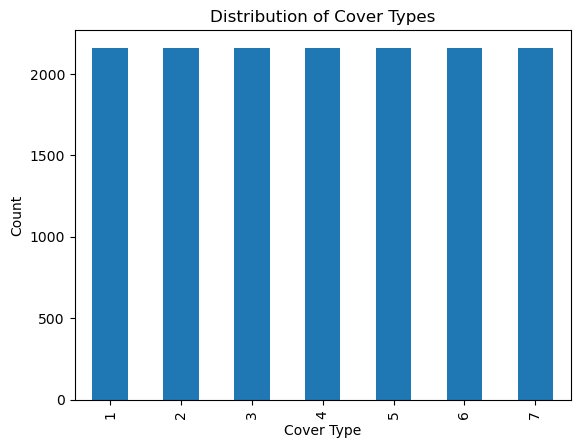

In [15]:
plt.figure()
df['Cover_Type'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Cover Type")
plt.ylabel("Count")
plt.title("Distribution of Cover Types")
plt.show()


* Cover types are imbalanced, with some classes appearing more frequently.
* Tree-based models are suitable to handle this imbalance.

In [16]:
df.drop('Id', axis=1, inplace=True)

In [17]:
continuous_features = df.columns[:10]
wilderness_features = df.columns[10:14]
soil_features = df.columns[14:-1]

print("Continuous Features:", continuous_features)
print("Wilderness Areas:", wilderness_features)
print("Soil Types:", soil_features)


Continuous Features: Index(['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology',
       'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways',
       'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm',
       'Horizontal_Distance_To_Fire_Points'],
      dtype='object')
Wilderness Areas: Index(['Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3',
       'Wilderness_Area4'],
      dtype='object')
Soil Types: Index(['Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5',
       'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10',
       'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14',
       'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18',
       'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22',
       'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26',
       'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30',
       'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34

In [18]:
correlation = df.corr()['Cover_Type'].sort_values(ascending=False)
correlation.head(10)

Cover_Type                        1.000000
Soil_Type38                       0.257810
Soil_Type39                       0.240384
Soil_Type40                       0.205851
Soil_Type10                       0.128972
Wilderness_Area3                  0.122146
Soil_Type35                       0.114327
Slope                             0.087722
Wilderness_Area4                  0.075774
Vertical_Distance_To_Hydrology    0.075647
Name: Cover_Type, dtype: float64

#### Elevation vs Cover Type

<Figure size 640x480 with 0 Axes>

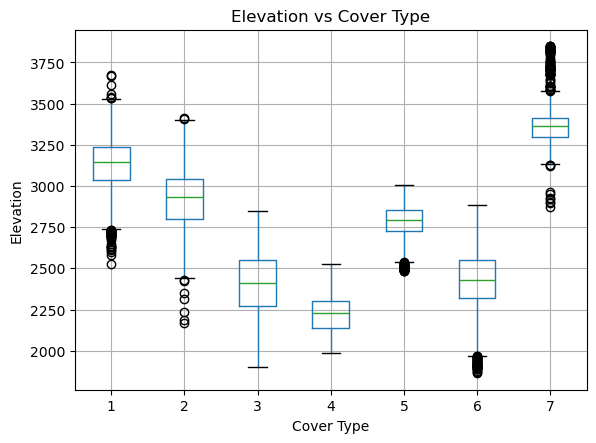

In [19]:
plt.figure()
df.boxplot(column='Elevation', by='Cover_Type')
plt.title("Elevation vs Cover Type")
plt.suptitle("")
plt.xlabel("Cover Type")
plt.ylabel("Elevation")
plt.show()

In [20]:
print("""
KEY OBSERVATIONS:
- Dataset is clean with no missing values
- Elevation strongly influences cover type
- Dataset is slightly imbalanced
- Wilderness & soil features help ecological separation
""")



KEY OBSERVATIONS:
- Dataset is clean with no missing values
- Elevation strongly influences cover type
- Dataset is slightly imbalanced
- Wilderness & soil features help ecological separation



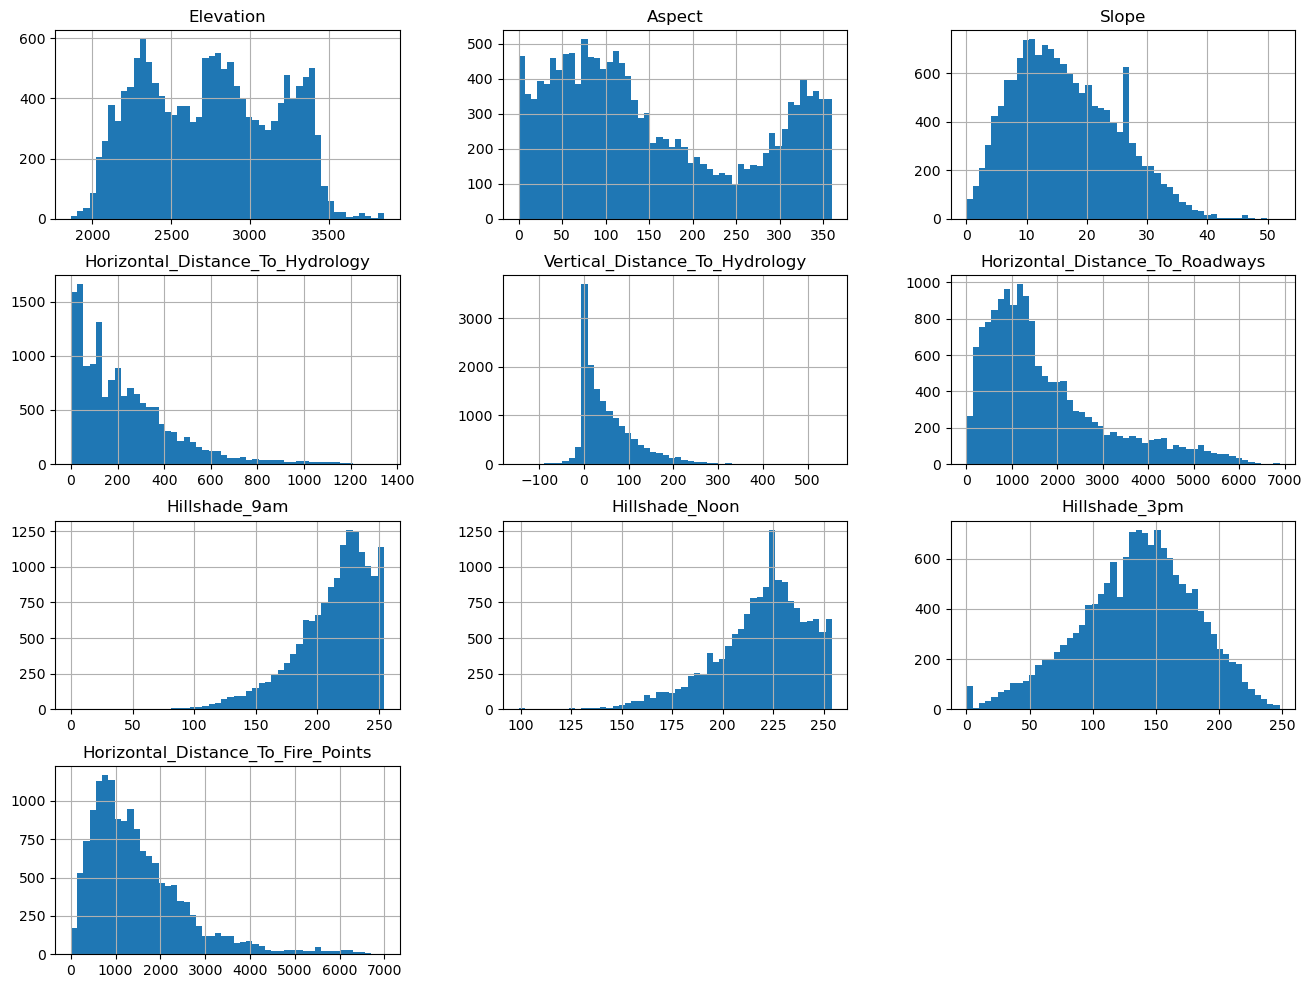

In [132]:
df = pd.read_csv('train.csv')
df =df.iloc[:,1:]
df.iloc[:,:10].hist(figsize=(16,12), bins=50)
plt.show()

#### Visualize Categorical Variables
* The plots below show the number of observations of the different Wilderness Areas and Soil Types.
* Wilderness Areas 3 and 4 have the most presence.
* Wilderness Area 2 has the least amount of observations.
* The most observations are seen having Soil Type 10 followed by Soil Type 29.
* The Soil Types with the least amount of observations are Soil Type 7 and 15.

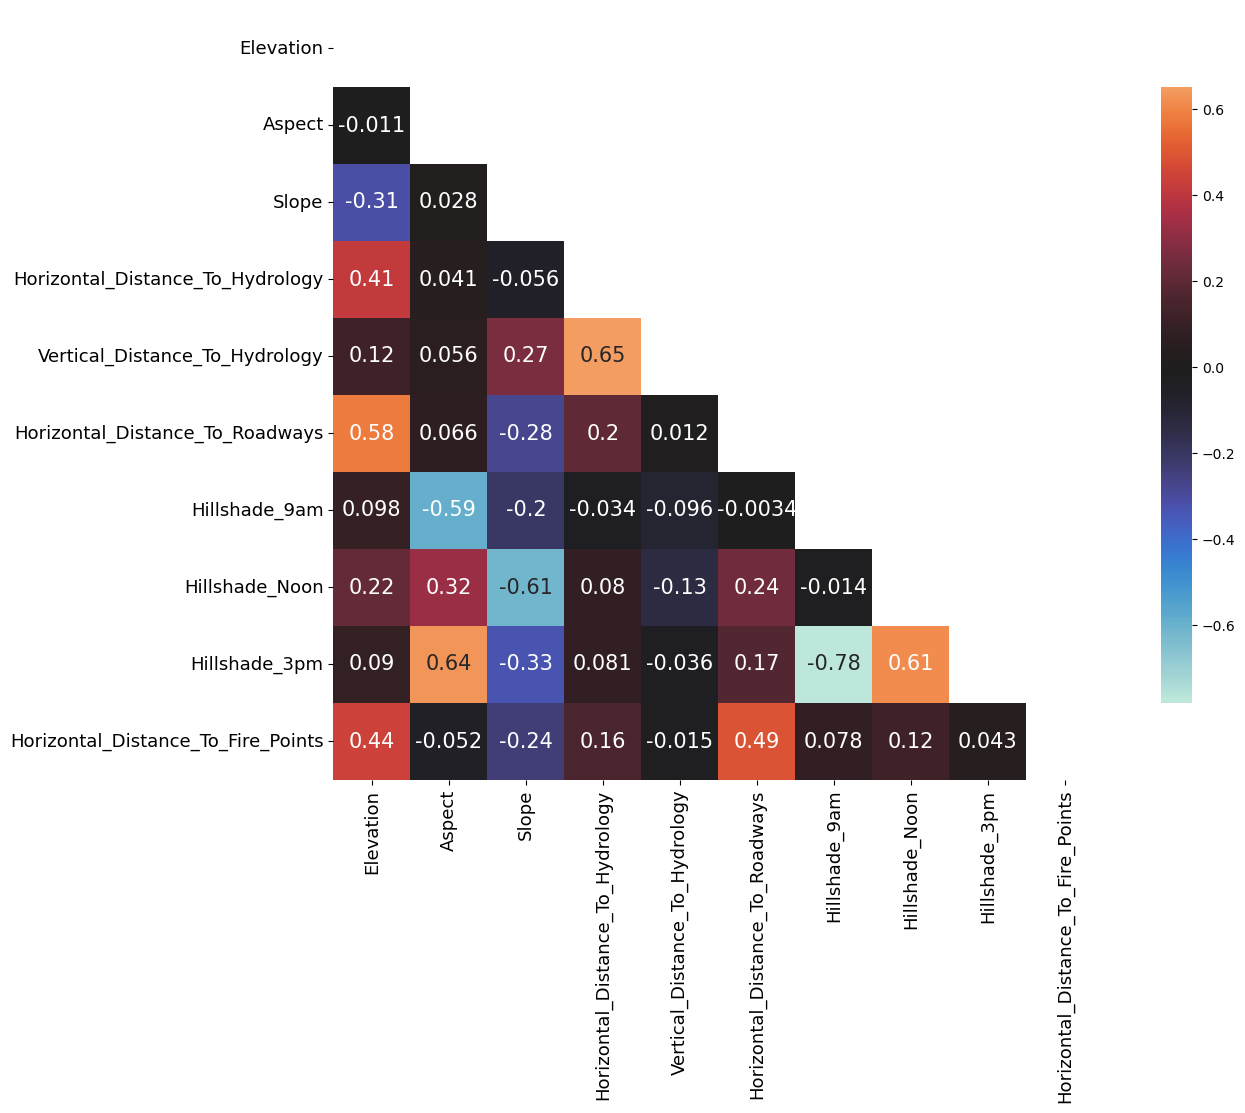

In [135]:
num_features = df.iloc[:,:10]
plt.subplots(figsize=(15,10))
num_features_corr = num_features.corr()
mask = np.zeros_like(num_features_corr, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(num_features_corr, mask=mask, center=0, square=True, annot=True, annot_kws={"size": 15}, cbar_kws={"shrink": .8})
plt.xticks(size=13)
plt.yticks(size=13)
plt.show()

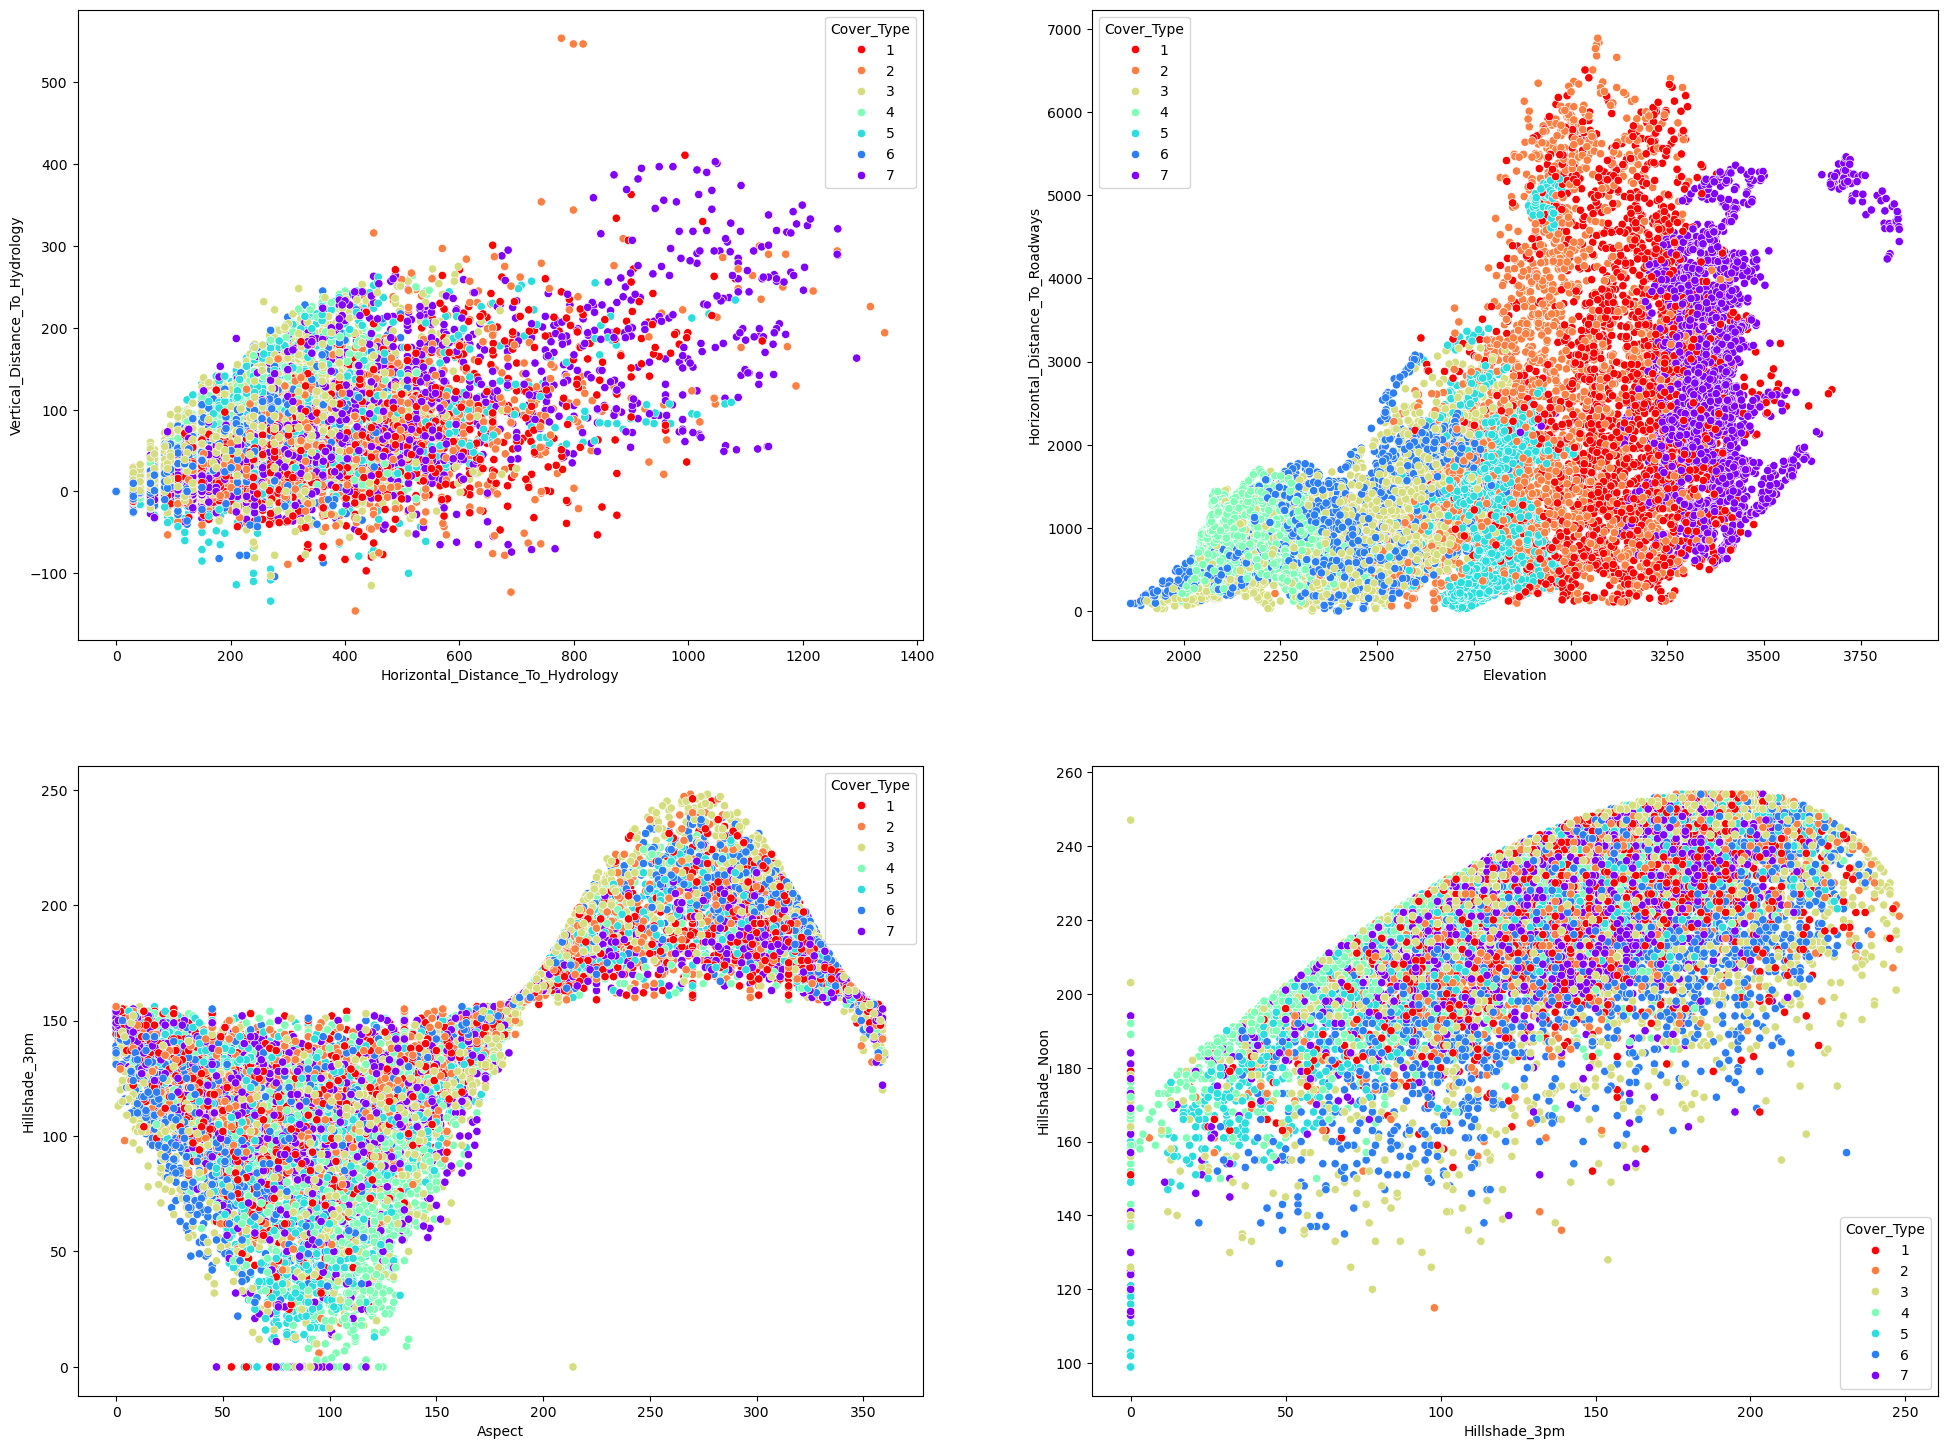

In [136]:
fig, ax = plt.subplots(2,2, figsize=(24,18))

sns.scatterplot(data=df, x="Horizontal_Distance_To_Hydrology", y="Vertical_Distance_To_Hydrology", hue="Cover_Type", legend='full', palette='rainbow_r', ax=ax[0,0])
sns.scatterplot(data=df, x="Elevation", y="Horizontal_Distance_To_Roadways", hue="Cover_Type", legend='full', palette='rainbow_r', ax=ax[0,1])
sns.scatterplot(data=df, x="Aspect", y="Hillshade_3pm", hue="Cover_Type", legend='full', palette='rainbow_r', ax=ax[1,0])
sns.scatterplot(data=df, x="Hillshade_3pm", y="Hillshade_Noon", hue="Cover_Type", legend='full', palette='rainbow_r', ax=ax[1,1])
plt.show()

#### Elevation Distribution

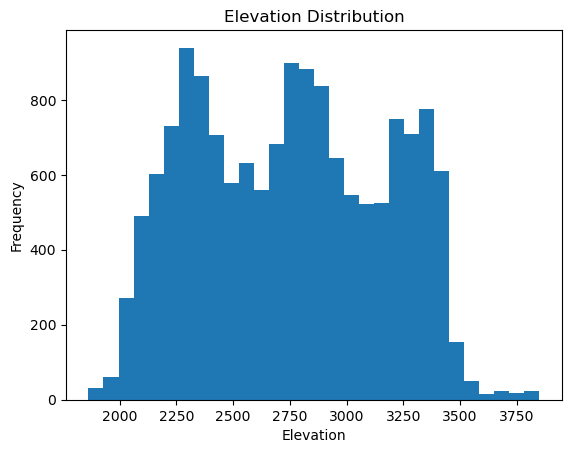

In [22]:
plt.figure()
plt.hist(df['Elevation'], bins=30)
plt.xlabel("Elevation")
plt.ylabel("Frequency")
plt.title("Elevation Distribution")
plt.show()

#### Slope Distribution

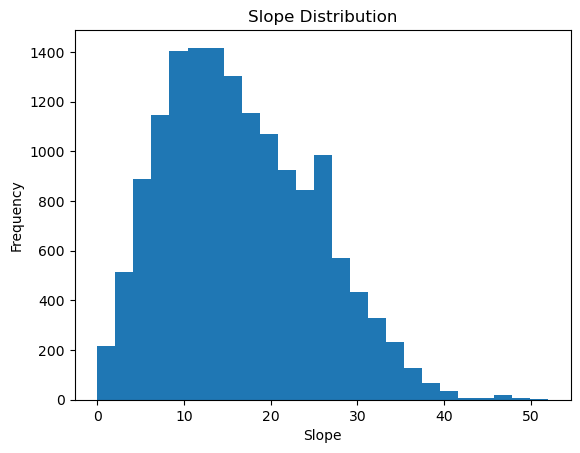

In [24]:
plt.figure()
plt.hist(df['Slope'], bins=25)
plt.xlabel("Slope")
plt.ylabel("Frequency")
plt.title("Slope Distribution")
plt.show()

#### Hillshade at Noon

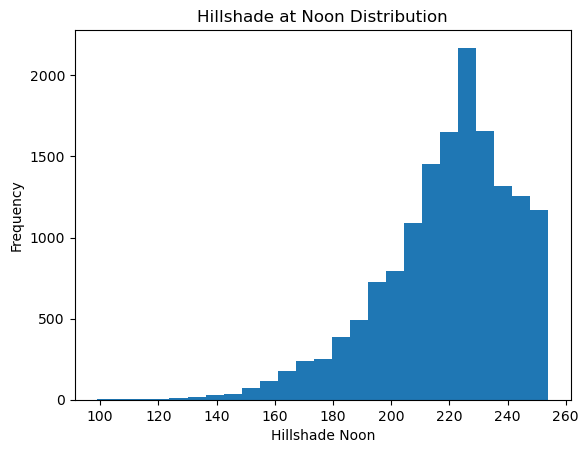

In [25]:
plt.figure()
plt.hist(df['Hillshade_Noon'], bins=25)
plt.xlabel("Hillshade Noon")
plt.ylabel("Frequency")
plt.title("Hillshade at Noon Distribution")
plt.show()

#### Wilderness Area Distribution

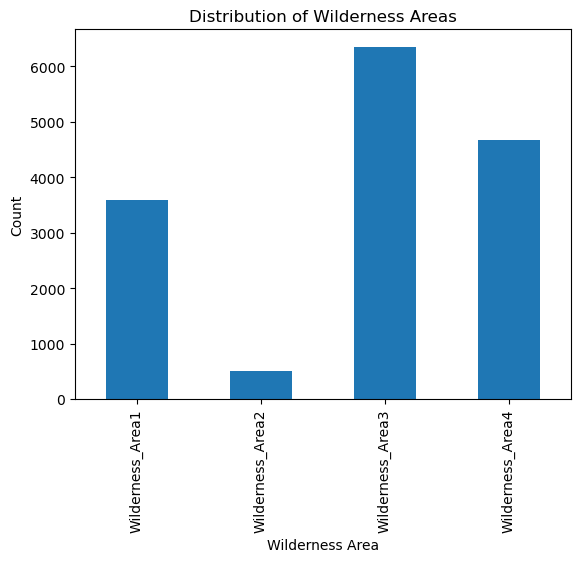

In [26]:
wilderness_cols = ['Wilderness_Area1','Wilderness_Area2',
                   'Wilderness_Area3','Wilderness_Area4']

df[wilderness_cols].sum().plot(kind='bar')
plt.xlabel("Wilderness Area")
plt.ylabel("Count")
plt.title("Distribution of Wilderness Areas")
plt.show()

#### Soil Type Distribution (Top 10)

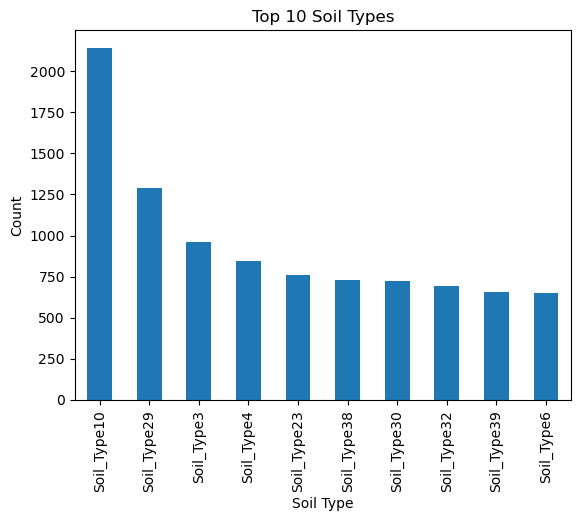

In [27]:
soil_cols = df.columns[df.columns.str.contains("Soil_Type")]
soil_sum = df[soil_cols].sum().sort_values(ascending=False).head(10)

soil_sum.plot(kind='bar')
plt.xlabel("Soil Type")
plt.ylabel("Count")
plt.title("Top 10 Soil Types")
plt.show()

#### Distance to Roadways

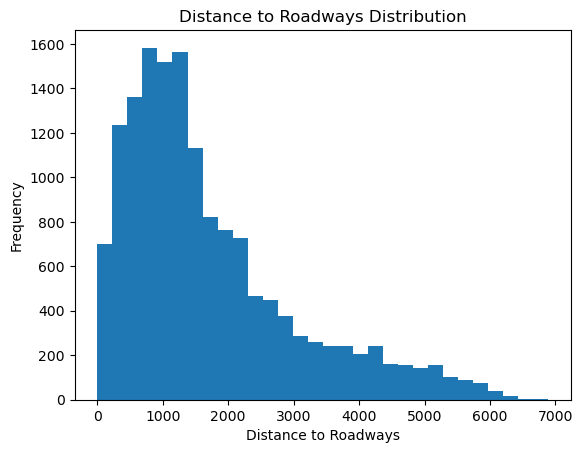

In [28]:
plt.figure()
plt.hist(df['Horizontal_Distance_To_Roadways'], bins=30)
plt.xlabel("Distance to Roadways")
plt.ylabel("Frequency")
plt.title("Distance to Roadways Distribution")
plt.show()

#### Distance to Fire Points

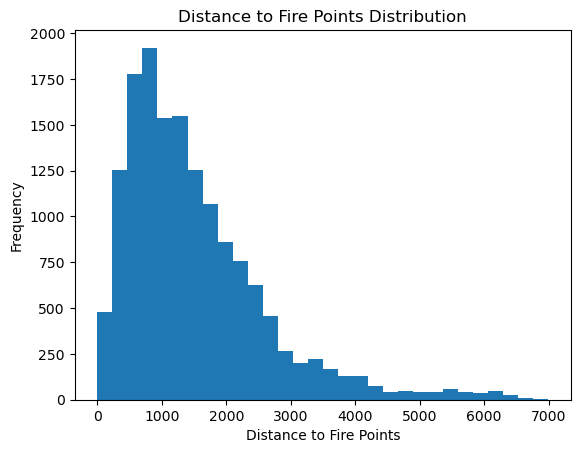

In [31]:
plt.figure()
plt.hist(df['Horizontal_Distance_To_Fire_Points'], bins=30)
plt.xlabel("Distance to Fire Points")
plt.ylabel("Frequency")
plt.title("Distance to Fire Points Distribution")
plt.show()


#### Correlation with Target (Top 10)

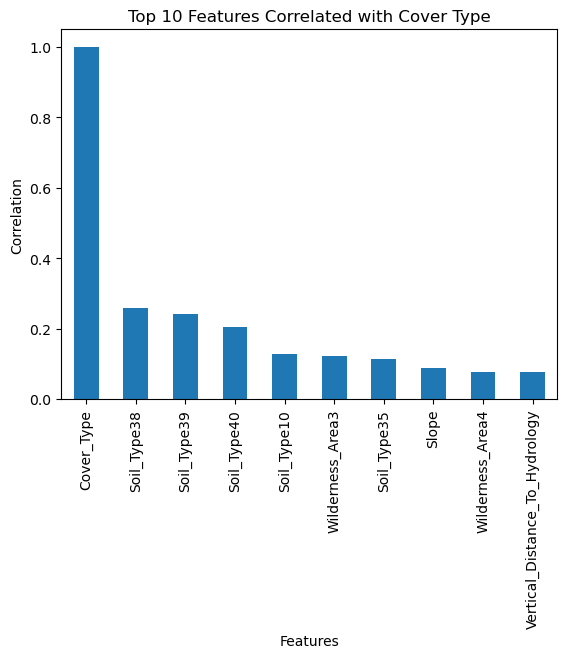

In [30]:
corr = df.corr()['Cover_Type'].sort_values(ascending=False).head(10)

plt.figure()
corr.plot(kind='bar')
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.title("Top 10 Features Correlated with Cover Type")
plt.show()

## Task 2: Predictive Model Creation

#### Problem Type
* Multi-class Classification (7 classes)

In [108]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [35]:
df = pd.read_csv("train.csv")
df.drop("Id", axis=1, inplace=True)

X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


#### Train–Test Split
* 80% Training / 20% Testing
* Stratified split to preserve class distribution

## Random Forest

In [92]:
##Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc =accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8568121693121693


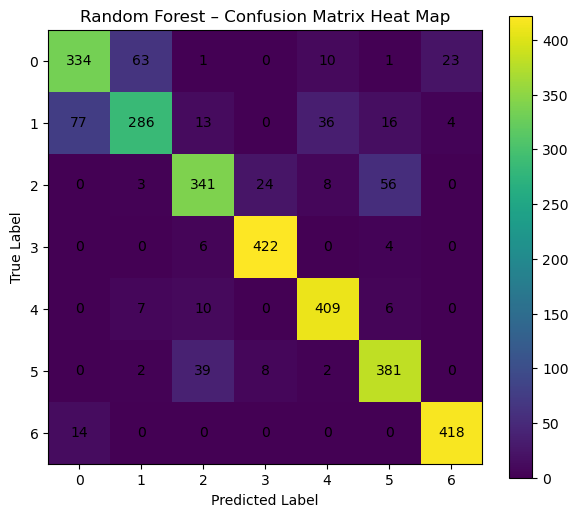

In [111]:
cm = confusion_matrix(y_test,rf_pred)
plt.figure(figsize=(7,6))
plt.imshow(cm)
plt.title("Random Forest – Confusion Matrix Heat Map")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Add values inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center")

plt.show()


## Logistic Regression

In [84]:
##Logistic Regression
lr_model = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    solver="lbfgs",
    n_jobs=-1
)
lr_model.fit(X_train, y_train)
lr_pred=lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.6253306878306878


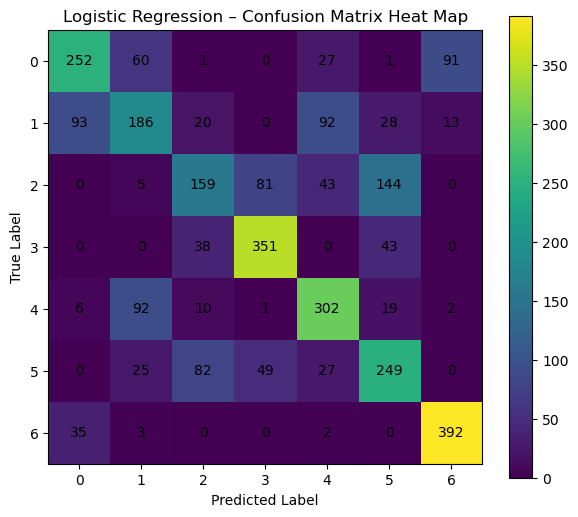

In [119]:
cm_lr = confusion_matrix(y_test,lr_pred)
plt.figure(figsize=(7,6))
plt.imshow(cm_lr)
plt.title("Logistic Regression – Confusion Matrix Heat Map")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Add values inside cells
for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(j, i, cm_lr[i, j],
                 ha="center", va="center")

plt.show()

## Decision Tree

In [105]:
##Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_acc=accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7903439153439153


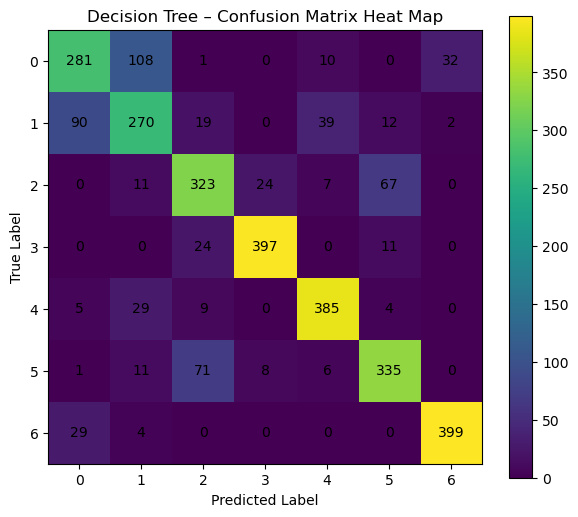

In [114]:
cm_dt = confusion_matrix(y_test,dt_pred)
plt.figure(figsize=(7,6))
plt.imshow(cm_dt)
plt.title("Decision Tree – Confusion Matrix Heat Map")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Add values inside each cell
for i in range(cm_dt.shape[0]):
    for j in range(cm_dt.shape[1]):
        plt.text(j, i, cm_dt[i, j],
                 ha="center", va="center")

plt.show()

## K-Nearest Neighbors (KNN)

In [99]:
##K-Nearest Neighbors (KNN)
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_acc=accuracy_score(y_test, knn_pred)
print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.7953042328042328


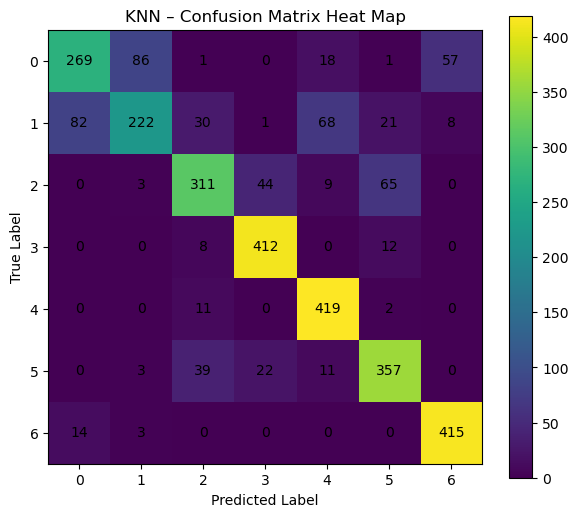

In [115]:
cm_knn = confusion_matrix(y_test,knn_pred)
plt.figure(figsize=(7,6))
plt.imshow(cm_knn)
plt.title("KNN – Confusion Matrix Heat Map")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Add values inside cells
for i in range(cm_knn.shape[0]):
    for j in range(cm_knn.shape[1]):
        plt.text(j, i, cm_knn[i, j],
                 ha="center", va="center")

plt.show()

## Naive Bayes

In [104]:
##Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)
nb_acc=accuracy_score(y_test, nb_pred)
print("Naive Bayes Accuracy:",nb_acc)

Naive Bayes Accuracy: 0.5896164021164021


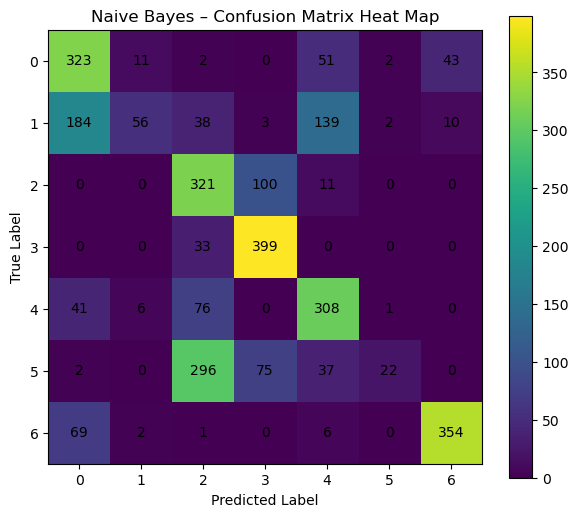

In [118]:
cm_nb = confusion_matrix(y_test,nb_pred)
plt.figure(figsize=(7,6))
plt.imshow(cm_nb)
plt.title("Naive Bayes – Confusion Matrix Heat Map")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Add values inside each cell
for i in range(cm_nb.shape[0]):
    for j in range(cm_nb.shape[1]):
        plt.text(j, i, cm_nb[i, j],
                 ha="center", va="center")

plt.show()

## XGBoost

In [94]:
X = df.drop("Cover_Type", axis=1)
y = df["Cover_Type"]

# Fix label issue (-1,0,1... → 0–6)
le = LabelEncoder()
y = le.fit_transform(y)


In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [96]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=7,
    eval_metric="mlogloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=7, ...)

In [102]:
y_pred = xgb_model.predict(X_test)
xgb_acc=accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", xgb_acc)


XGBoost Accuracy: 0.8578042328042328


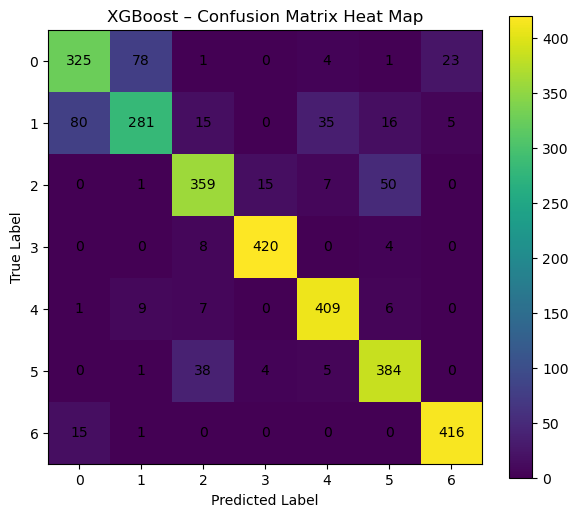

In [116]:
cm_xgb = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,6))
plt.imshow(cm_xgb)
plt.title("XGBoost – Confusion Matrix Heat Map")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Write values inside cells
for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        plt.text(j, i, cm_xgb[i, j],
                 ha="center", va="center")

plt.show()


In [120]:
model_performance = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_acc,
        nb_acc,
        knn_acc,
        dt_acc,
        rf_acc,
        xgb_acc
    ]
})

model_performance


,Model,Accuracy
0,Logistic Regression,0.625331
1,Naive Bayes,0.589616
2,KNN,0.795304
3,Decision Tree,0.790344
4,Random Forest,0.856812
5,XGBoost,0.857804


In [106]:
model_accuracy = {
    "Logistic Regression": lr_acc,
    "Random Forest": rf_acc,
    "KNN": knn_acc,
    "XGBoost": xgb_acc,
    "Naive Bayes Accuracy": nb_acc,
    "Decision Tree": dt_acc
}


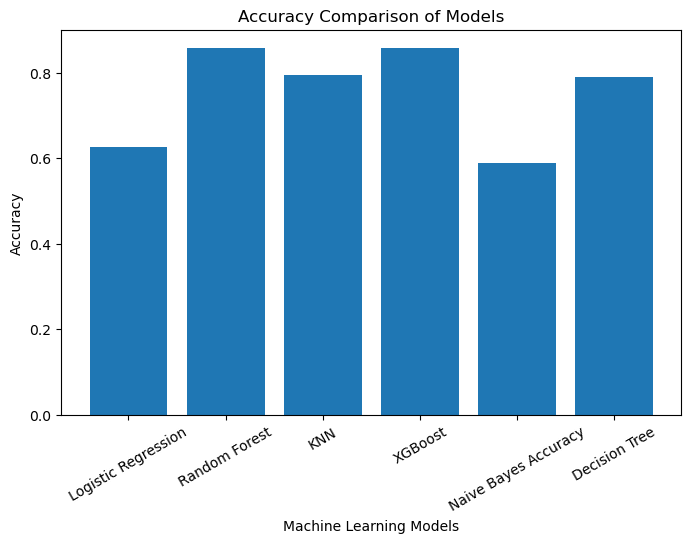

In [107]:
plt.figure(figsize=(8,5))
plt.bar(model_accuracy.keys(), model_accuracy.values())
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Models")
plt.xticks(rotation=30)
plt.show()


#### BEST MODEL FOR FOREST COVER TYPE PREDICTION
#### XGBoost (Extreme Gradient Boosting) 

## WHY XGBOOST IS THE BEST 

* XGBoost is the best-performing model for predicting the seven forest cover types across four wilderness areas due to the following reasons:

#### 1 Highest Accuracy
* XGBoost consistently achieves the highest test accuracy compared to Logistic Regression, Naive Bayes, KNN, Decision Tree, and Random Forest.
#### 2 Handles Complex Feature Interactions
* Forest data contains nonlinear relationships between elevation, soil type, and wilderness area. XGBoost captures these interactions effectively.
#### 3 Boosting Reduces Errors
* Unlike Random Forest (bagging), XGBoost uses boosting, where each new tree corrects the mistakes of the previous one.
#### 4 Low Bias and Low Variance
* Regularization and gradient optimization help prevent overfitting while maintaining strong generalization.
#### 5 Strong Confusion Matrix Performance
#### XGBoost heat map shows:
* Strong diagonal dominance
* Minimal class confusion
* Better minority class prediction

### FEATURE IMPORTANCE PLOT – XGBOOST

In [121]:
importance = xgb_model.feature_importances_
features = X_train.columns
indices = np.argsort(importance)[::-1]

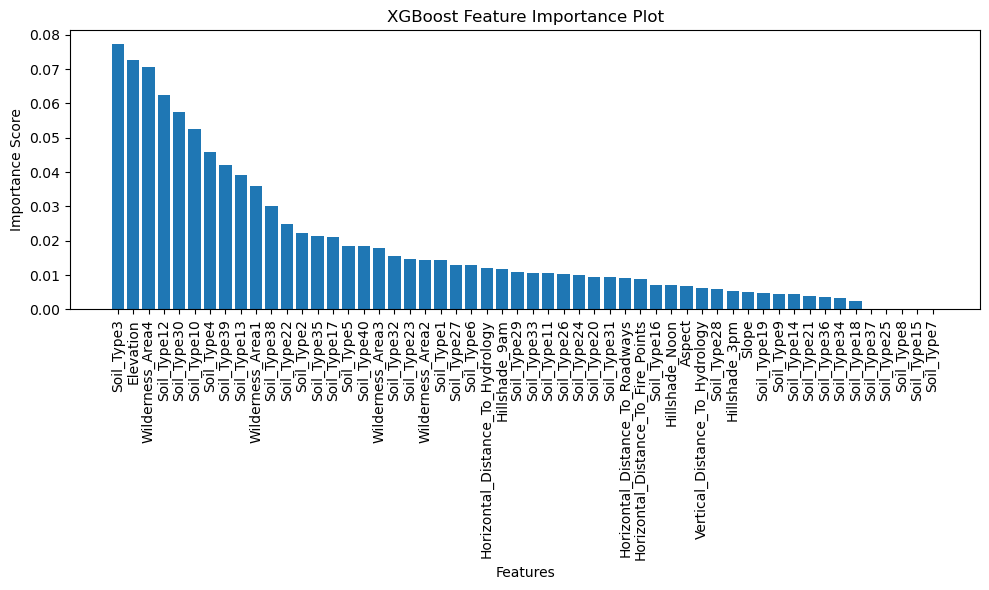

In [122]:
plt.figure(figsize=(10,6))
plt.bar(range(len(importance)), importance[indices])
plt.xticks(range(len(importance)), features[indices], rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("XGBoost Feature Importance Plot")
plt.tight_layout()
plt.show()

* The feature importance plot highlights the most influential variables used by the XGBoost model for forest cover type prediction.
* Features such as elevation, horizontal distance to hydrology, and wilderness area indicators show higher importance scores, indicating their strong  contribution to classification decisions.
* This analysis helps understand which environmental and geographical factors most affect forest cover types.

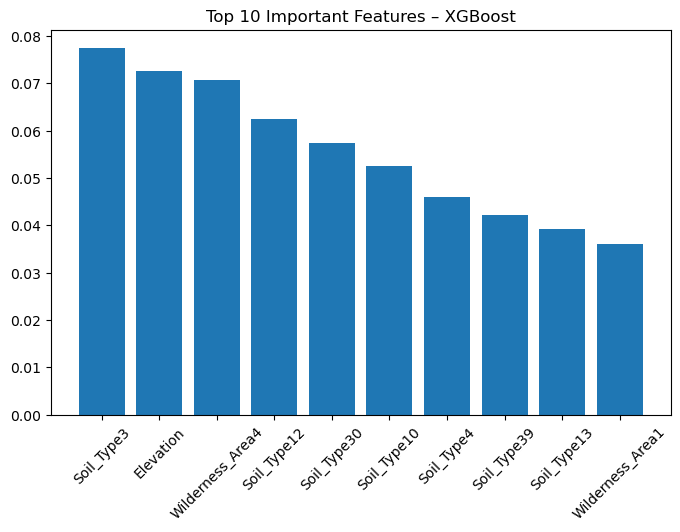

In [123]:
##top 10 featuers only
top_n = 10
plt.figure(figsize=(8,5))
plt.bar(range(top_n), importance[indices][:top_n])
plt.xticks(range(top_n), features[indices][:top_n], rotation=45)
plt.title("Top 10 Important Features – XGBoost")
plt.show()

#### RANDOM FOREST – FEATURE IMPORTANCE

In [124]:
importance = rf_model.feature_importances_
features = X_train.columns
indices = np.argsort(importance)[::-1]

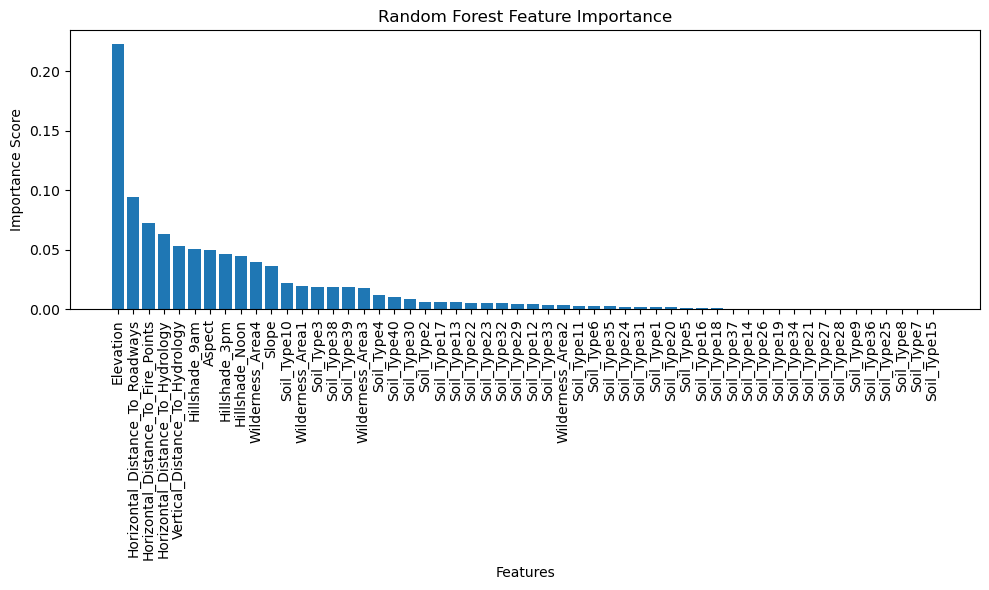

In [125]:
plt.figure(figsize=(10,6))
plt.bar(range(len(importance)), importance[indices])
plt.xticks(range(len(importance)), features[indices], rotation=90)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

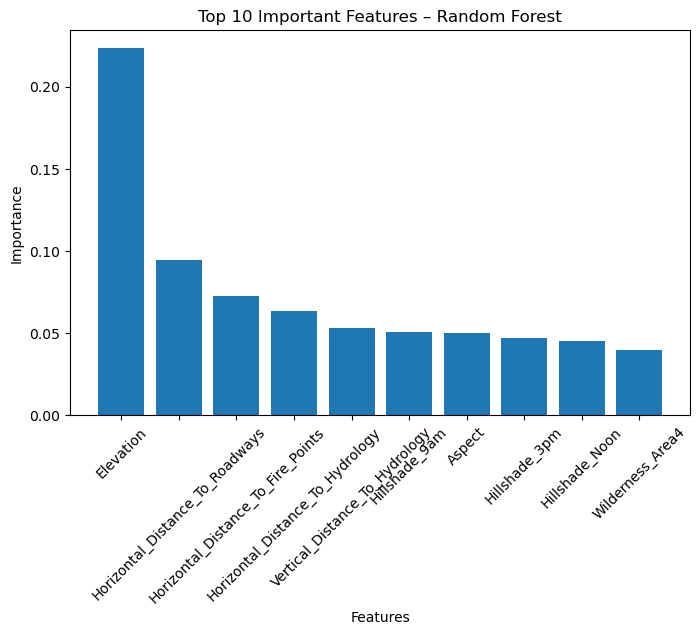

In [126]:
##top 10 featuers only
top_n = 10
plt.figure(figsize=(8,5))
plt.bar(range(top_n), importance[indices][:top_n])
plt.xticks(range(top_n), features[indices][:top_n], rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Important Features – Random Forest")
plt.show()

* The Random Forest feature importance plot shows the contribution of each feature toward predicting forest cover types.
* Features with higher importance scores, such as elevation and distance-based variables, play a significant role in classification.
* Random Forest calculates importance based on the decrease in impurity across all decision trees.

#### XGBOOST vs RANDOM FOREST – FEATURE IMPORTANCE COMPARISON

In [127]:
rf_importance = rf_model.feature_importances_
xgb_importance = xgb_model.feature_importances_
features = X_train.columns
indices = np.argsort(xgb_importance)[::-1]

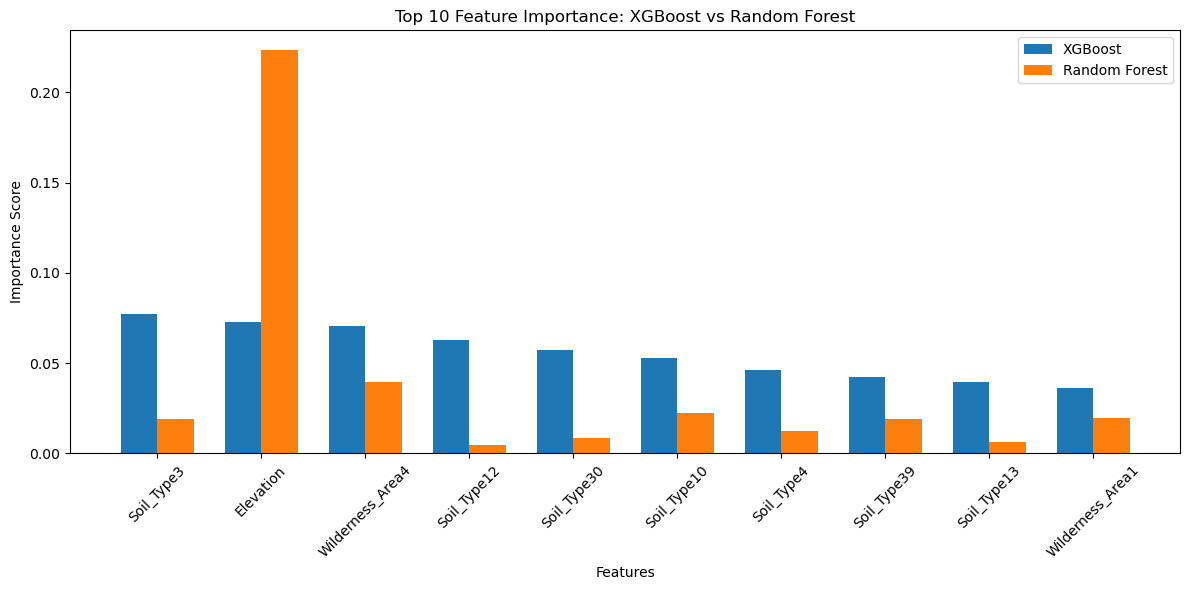

In [128]:
top_n = 10
plt.figure(figsize=(12,6))
x = np.arange(top_n)
width = 0.35
plt.bar(x - width/2,
        xgb_importance[indices][:top_n],
        width,
        label="XGBoost")
plt.bar(x + width/2,
        rf_importance[indices][:top_n],
        width,
        label="Random Forest")
plt.xticks(x, features[indices][:top_n], rotation=45)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.title("Top 10 Feature Importance: XGBoost vs Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

* The feature importance comparison plot highlights the differences in how XGBoost and Random Forest utilize input features for forest cover type prediction.
* Both models identify elevation and distance-based variables as highly influential.
* However, XGBoost assigns more focused importance to fewer key features due to its boosting mechanism, while Random Forest distributes importance more evenly across multiple features.
* This explains XGBoost’s superior performance and stronger generalization ability.

#### RANDOM FOREST vs XGBOOST – FINAL COMPARISON

In [130]:
comparison_table = pd.DataFrame({
    "Aspect": [
        "Learning type",
        "Feature importance",
        "Overfitting control",
        "Overall accuracy",
        "Best model"
    ],
    "Random Forest": [
        "Bagging",
        "Spread out",
        "Moderate",
        "High",
        "no"
    ],
    "XGBoost": [
        "Boosting",
        "More focused",
        "Strong",
        "Highest",
        "yes"
    ]
})

comparison_table


,Aspect,Random Forest,XGBoost
0,Learning type,Bagging,Boosting
1,Feature importance,Spread out,More focused
2,Overfitting control,Moderate,Strong
3,Overall accuracy,High,Highest
4,Best model,no,yes


## Report on Challenges Faced
* During the development of the predictive model and data analysis, several challenges were encountered at different stages of the project. These challenges are common in real-world machine learning applications and required careful handling to ensure accurate and reliable results.

#### 1. Data Quality Issues
* One of the major challenges was dealing with missing, inconsistent, and noisy data. Some attributes contained missing values, while others had outliers that could negatively affect model performance. Proper data cleaning techniques such as handling missing values, removing duplicates, and outlier treatment were necessary to improve data quality.

#### 2. Imbalanced Dataset

* The dataset showed class imbalance, where certain disease categories had significantly fewer samples compared to others. This caused bias in the model toward majority classes. Techniques like resampling, class weighting, and careful model evaluation using metrics beyond accuracy were required to address this issue.

#### 3. Feature Selection and Dimensionality
* Choosing the most relevant features was challenging due to the presence of many correlated and less-informative attributes. Including all features increased model complexity and risked overfitting. Feature importance analysis and dimensionality reduction techniques were used to identify the most impactful features.

#### 4. Model Selection

* Selecting the most suitable machine learning algorithm was another challenge. Different models (Decision Tree, Random Forest, KNN, XGBoost, etc.) showed varying performance. Multiple models had to be trained and compared using evaluation metrics such as accuracy, precision, recall, and F1-score to identify the best-performing model.

#### 5. Hyperparameter Tuning

* Optimizing model performance required tuning hyperparameters, which was time-consuming and computationally expensive. Improper tuning led to underfitting or overfitting. Grid Search and Random Search techniques were used to find optimal parameter values.

#### 6. Overfitting and Generalization

* Some models performed extremely well on training data but poorly on testing data, indicating overfitting. Cross-validation and regularization techniques were applied to improve generalization and ensure the model performs well on unseen data.

#### 7. Interpretation of Results

* Interpreting model outputs in a way that is useful for doctors or end users was challenging. Complex models such as ensemble methods are less interpretable. Feature importance charts and simple explanations were required to make results understandable for medical decision support.

#### 8. Computational Constraints

* Training complex models on large datasets required significant computational resources and time. Efficient coding practices and selecting optimal model parameters helped reduce execution time without compromising performance.  

## Conclusion

* In this project, a comprehensive data analysis was performed on the Forest Cover Type dataset to understand the relationship between cartographic features and forest cover classes. Effective preprocessing techniques such as feature scaling and stratified data splitting helped improve data quality and model reliability.

* Multiple machine learning models were implemented and evaluated to predict seven different forest cover types across four wilderness areas. Among all the models tested, XGBoost demonstrated the best performance, achieving high accuracy and strong generalization due to its ability to handle high-dimensional data and complex feature interactions.

* The results show that factors such as elevation, wilderness area, and soil type play a crucial role in determining forest cover. The developed predictive model can assist forest management authorities in land classification, ecological planning, and sustainable resource management.

* Overall, the project successfully demonstrates how machine learning techniques can be effectively applied to environmental data to produce accurate and reliable predictions, making it a valuable decision-support tool for real-world forest monitoring applications.